In [1]:
import pandas as pd

df = pd.read_csv("../data/ecommerce_dataset.csv")

# Этап 1. Подготовка данных

## 1. Изучение данных

In [2]:
df.head()

,order_id,order_date,customer_id,customer_age,gender,region,product_name,category,quantity,unit_price,discount_percent,order_amount,customer_segment,is_repeat_customer,delivery_days,customer_rating
0,ORD-100000,2024-08-16,CUST-1035,65.0,Male,Saint Petersburg,AirPods Pro,Headphones,2,250,5,475.0,Business,True,1.0,NaN
1,ORD-100001,2025-10-27,CUST-1179,52.0,Female,Novosibirsk,iPhone 15,Smartphones,2,900,25,1350.0,Business,False,1.0,4.5
2,ORD-100002,2024-08-08,CUST-1195,39.0,Male,Saint Petersburg,Google Pixel 9,Smartphones,1,800,5,760.0,Business,True,NaN,NaN
3,ORD-100003,2024-05-07,CUST-1096,23.0,Female,Krasnodar,AirPods Pro,Headphones,2,250,20,400.0,Standard,True,1.0,4.3
4,ORD-100004,2024-04-13,CUST-1097,35.0,Female,Krasnodar,PlayStation 5,Consoles,3,600,30,1260.0,Standard,False,6.0,3.4


In [3]:
df.shape

(508, 16)

Количество строк в датасете: 508.

Количество столбцов в датасете: 16.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            508 non-null    str    
 1   order_date          508 non-null    str    
 2   customer_id         508 non-null    str    
 3   customer_age        483 non-null    float64
 4   gender              493 non-null    str    
 5   region              508 non-null    str    
 6   product_name        508 non-null    str    
 7   category            508 non-null    str    
 8   quantity            508 non-null    int64  
 9   unit_price          508 non-null    int64  
 10  discount_percent    508 non-null    int64  
 11  order_amount        508 non-null    float64
 12  customer_segment    508 non-null    str    
 13  is_repeat_customer  508 non-null    bool   
 14  delivery_days       473 non-null    float64
 15  customer_rating     457 non-null    float64
dtypes: bool(1), float64

Числовые признаки: типы int и float.

Категориальные признаки: str.

Булевые значения: bool.

Столбец order_date нужно будет привести к типу datetime.

In [5]:
df.isnull().sum()

order_id               0
order_date             0
customer_id            0
customer_age          25
gender                15
region                 0
product_name           0
category               0
quantity               0
unit_price             0
discount_percent       0
order_amount           0
customer_segment       0
is_repeat_customer     0
delivery_days         35
customer_rating       51
dtype: int64

Пропуски присутствуют в столбцах customer_age, gender, delivery_dates и customer_rating.

Наибольшее количество пропусков в столбце customer_rating.

Пропуски в столбцах customer_age и gender можно будет удалить.

Пропуски в столбцах delivery_dates и customer_rating, при необходимости, можно будет привести к среднему значению.

In [6]:
df.duplicated().sum()

np.int64(7)

В датасете обнаружено 7 дубликатов. 

В ходе анализа можно будет оценить необходимость их удаления.

In [7]:
df.describe()

,customer_age,quantity,unit_price,discount_percent,order_amount,delivery_days,customer_rating
count,483.000000,508.000000,508.000000,508.000000,508.000000,473.000000,457.000000
mean,43.954451,2.480315,658.966535,15.856299,1407.021654,5.498943,4.009847
std,18.005243,9.876836,455.886942,10.787760,6106.401935,2.884885,0.567438
min,-5.000000,-3.000000,-500.000000,0.000000,-1852.500000,1.000000,3.000000
25%,30.000000,1.000000,250.000000,5.000000,243.125000,3.000000,3.500000
50%,44.000000,1.000000,700.000000,15.000000,765.000000,6.000000,4.000000
75%,57.000000,3.000000,900.000000,25.000000,1350.000000,8.000000,4.500000
max,250.000000,200.000000,1500.000000,120.000000,98000.000000,10.000000,5.000000


In [8]:
df[df['quantity'] < 0]

,order_id,order_date,customer_id,customer_age,gender,region,product_name,category,quantity,unit_price,discount_percent,order_amount,customer_segment,is_repeat_customer,delivery_days,customer_rating
15,ORD-100015,2024-10-12,CUST-1171,49.0,Male,Kazan,Xiaomi 14,Smartphones,-3,650,5,-1852.5,Business,True,8.0,4.6


In [9]:
df[(df['customer_age'] < 0) | (df['customer_age'] > 90)]

,order_id,order_date,customer_id,customer_age,gender,region,product_name,category,quantity,unit_price,discount_percent,order_amount,customer_segment,is_repeat_customer,delivery_days,customer_rating
5,ORD-100005,2025-06-30,CUST-1186,-5.0,Male,Vladivostok,MacBook Air M3,Laptops,2,1400,5,2660.0,Business,False,9.0,3.4
10,ORD-100010,2024-07-01,CUST-1129,250.0,Female,Novosibirsk,Xiaomi TV,TVs,5,700,30,2450.0,Standard,False,3.0,4.1


In [10]:
df[df['unit_price'] < 0]

,order_id,order_date,customer_id,customer_age,gender,region,product_name,category,quantity,unit_price,discount_percent,order_amount,customer_segment,is_repeat_customer,delivery_days,customer_rating
25,ORD-100025,2024-08-03,CUST-1183,39.0,Male,Yekaterinburg,Samsung Galaxy S24,Smartphones,1,-500,20,-400.0,Business,False,1.0,3.2


In [11]:
df[(df['discount_percent'] < 0) | (df['discount_percent'] > 100)]

,order_id,order_date,customer_id,customer_age,gender,region,product_name,category,quantity,unit_price,discount_percent,order_amount,customer_segment,is_repeat_customer,delivery_days,customer_rating
20,ORD-100020,2024-03-03,CUST-1191,38.0,Male,Moscow,iPhone 15,Smartphones,2,900,120,-360.0,Business,True,1.0,4.9


In [12]:
df[df['order_amount'] < 0]

,order_id,order_date,customer_id,customer_age,gender,region,product_name,category,quantity,unit_price,discount_percent,order_amount,customer_segment,is_repeat_customer,delivery_days,customer_rating
15,ORD-100015,2024-10-12,CUST-1171,49.0,Male,Kazan,Xiaomi 14,Smartphones,-3,650,5,-1852.5,Business,True,8.0,4.6
20,ORD-100020,2024-03-03,CUST-1191,38.0,Male,Moscow,iPhone 15,Smartphones,2,900,120,-360.0,Business,True,1.0,4.9
25,ORD-100025,2024-08-03,CUST-1183,39.0,Male,Yekaterinburg,Samsung Galaxy S24,Smartphones,1,-500,20,-400.0,Business,False,1.0,3.2


In [13]:
df[(df['customer_rating'] < 0) | (df['customer_rating'] > 100)]

,order_id,order_date,customer_id,customer_age,gender,region,product_name,category,quantity,unit_price,discount_percent,order_amount,customer_segment,is_repeat_customer,delivery_days,customer_rating


### Найденные аномалии при первичном анализе датасета:

'quantity' - заказ отрицательного количества товара. 

'customer_age' - нереалистичные возрасты клиентов(-5 и 250 лет). 

'unit_price' - отрицательная цена товара. 

'discount_percent' - процент скидки больше 100% или меньше 0%. 

'order_amount' - отрицательная сумма заказа. 


Данные наблюдения требуют дальнейшей проверки и возможной очистки. 

## 2. Работа с пропусками

### В следующих столбцах были обнаружены пропущенные значения:

In [14]:
df = df.drop_duplicates()

Пропуски были удалены, так как представляют повторные заказы с идентичными параметрами и могут искажать статистику продаж и поведенческий анализ клиентов.

In [15]:
df.isnull().sum()

order_id               0
order_date             0
customer_id            0
customer_age          25
gender                15
region                 0
product_name           0
category               0
quantity               0
unit_price             0
discount_percent       0
order_amount           0
customer_segment       0
is_repeat_customer     0
delivery_days         35
customer_rating       50
dtype: int64

In [16]:
df['gender'].value_counts(dropna=False)

gender
Male      245
Female    241
NaN        15
Name: count, dtype: int64

В поле 'gender' было принято решение оставить пропущенные значения без изменений, так как пол клиента невозможно достоверно восстановить.

Была проведена проверка, что пустые ячейки уже читаются как NaN. 

In [17]:
df['customer_age'] =df['customer_age'].fillna(df['customer_age'].median())

Было принято решение заменить пропуски в столбце 'customer_age' на медиану, так как при использовании среднего значения они могут быть искажены обнаруженными выбросами, которые могут повлиять на дальнейший анализ. 

In [18]:
df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].median())

Было принято решение заменить пропуски в столбце 'customer_rating' на медиану, так как при использовании среднего значения выброс может испортить действительную оценку покупателей. 

In [19]:
df['delivery_days'] = df['delivery_days'].fillna(df['delivery_days'].mean())

Было принято решение заменить пропуски в столбце 'delivery_days' на среднее значение, так как анализ не выявил выраженных выбросов в сроках доставки. В данном случае среднее значение даст большее понимание ситуации. 

In [20]:
df.isnull().sum()

order_id               0
order_date             0
customer_id            0
customer_age           0
gender                15
region                 0
product_name           0
category               0
quantity               0
unit_price             0
discount_percent       0
order_amount           0
customer_segment       0
is_repeat_customer     0
delivery_days          0
customer_rating        0
dtype: int64

После обработки пропусков значения NaN были устранены. Пропуски в gender были оставлены без изменений. 

## 3. Удаление некачественных данных

In [21]:
df[df['quantity'] <= 0].sum()

order_id               ORD-100015
order_date             2024-10-12
customer_id             CUST-1171
customer_age                 49.0
gender                       Male
region                      Kazan
product_name            Xiaomi 14
category              Smartphones
quantity                       -3
unit_price                    650
discount_percent                5
order_amount              -1852.5
customer_segment         Business
is_repeat_customer              1
delivery_days                 8.0
customer_rating               4.6
dtype: object

In [22]:
((df['customer_age'] < 0) | (df['customer_age'] > 100)).sum()

np.int64(2)

In [23]:
(df['unit_price'] <= 0).sum()

np.int64(1)

In [24]:
((df['discount_percent'] < 0) | (df['discount_percent'] > 100)).sum()

np.int64(1)

In [25]:
(df['order_amount'] <= 0).sum()

np.int64(3)

Была проведена проверка, показывающая, что количество записей с некорректными данными очень мало, что говорит о случайных ошибках при заполнении, а не о некорректности всего датасета.

In [26]:
df = df[df['quantity'] > 0]
df[df['quantity'] <= 0].sum()

order_id                 
order_date               
customer_id              
customer_age          0.0
gender                   
region                   
product_name             
category                 
quantity                0
unit_price              0
discount_percent        0
order_amount          0.0
customer_segment         
is_repeat_customer      0
delivery_days         0.0
customer_rating       0.0
dtype: object

In [27]:
df = df[df['unit_price'] > 0]
df[df['unit_price'] <= 0].sum()

order_id                 
order_date               
customer_id              
customer_age          0.0
gender                   
region                   
product_name             
category                 
quantity                0
unit_price              0
discount_percent        0
order_amount          0.0
customer_segment         
is_repeat_customer      0
delivery_days         0.0
customer_rating       0.0
dtype: object

In [28]:
df = df[(df['discount_percent'] >= 0) & (df['discount_percent'] <= 100)]
df[(df['discount_percent'] < 0) | (df['discount_percent'] > 100)].sum()

order_id                 
order_date               
customer_id              
customer_age          0.0
gender                   
region                   
product_name             
category                 
quantity                0
unit_price              0
discount_percent        0
order_amount          0.0
customer_segment         
is_repeat_customer      0
delivery_days         0.0
customer_rating       0.0
dtype: object

In [29]:
df = df[df['order_amount'] > 0]
df[df['order_amount'] <= 0].sum()

order_id                 
order_date               
customer_id              
customer_age          0.0
gender                   
region                   
product_name             
category                 
quantity                0
unit_price              0
discount_percent        0
order_amount          0.0
customer_segment         
is_repeat_customer      0
delivery_days         0.0
customer_rating       0.0
dtype: object

In [56]:
df = df[(df['customer_age'] >= 18) & (df['customer_age'] <= 90)]
df['customer_age'] = df['customer_age'].fillna(df['customer_age'].median())

Чтобы избежать искажения результатов анализа, были удалены все записи с некорректными значениями(кроме 'customer_age'), которые не могли соответствовать реальным данным. 

Некорректные записи в 'customer_age' были приведены к медианному значению, так как этот метод позволяет сохранить более реалистичное распределение возраста клиентов. 

## 4. Работа с выбросами

In [48]:
df[['quantity', 'unit_price', 'order_amount', 'discount_percent', 'customer_age']].describe()

,quantity,unit_price,order_amount,discount_percent,customer_age
count,498.000000,498.000000,498.000000,498.000000,498.000000
mean,2.485944,657.540161,1406.093373,15.722892,43.881526
std,9.970016,455.237377,6160.599106,9.759663,17.623494
min,1.000000,15.000000,10.500000,0.000000,-5.000000
25%,1.000000,250.000000,245.000000,5.000000,30.000000
50%,1.000000,700.000000,765.000000,15.000000,44.000000
75%,3.000000,900.000000,1350.000000,25.000000,56.000000
max,200.000000,1500.000000,98000.000000,30.000000,250.000000


### В ходе анализа с использованием описательсной статистики были обнаружены потенциальные выбросы:

'quantity' -  в данном столбце наблюдается значительный разрыв между значениями '75%' и 'max', что показывает наличие особо крупных заказов.  

'order_amount' -  в данном столбце наблюдается экстремально высокое значение, что показывает наличие особо высокой суммы заказа, которая может влиять на среднее показание выручки. 

В столбцах 'unit_price', 'discount_price' и 'customer_age' существенные отклонения отсутствуют.

Так как значения 'quantity' и 'order_amount' могут отражать реальные крупные покупки, они не были удалены и оставлены для дальнейшего анализа.

## 5. Подготовка итогового датасета

In [32]:
df_raw = pd.read_csv("../data/ecommerce_dataset.csv")

removed_rows = df_raw.shape[0] - df.shape[0]

print(df_raw.shape[0], df.shape[0], removed_rows)

508 498 10


Количество записей до обработки: 508. 

Количество записей после обработки: 498. 

Количество удаленных записей: 10. 

### Основные изменения в данных:

обработаны пропуски в признаках `customer_age`, `customer_rating`, `delivery_days` и  `gender`. 

некорректные числовые признаки были удалены или приведены к корректному виду. 

удалены записи с невозможными значениями. 

обработаны выбросы. часть экстремальных значений оставлена для корректности анализа. 

# Этап 2. Исследовательский анализ

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df.head()

,order_id,order_date,customer_id,customer_age,gender,region,product_name,category,quantity,unit_price,discount_percent,order_amount,customer_segment,is_repeat_customer,delivery_days,customer_rating
0,ORD-100000,2024-08-16,CUST-1035,65.0,Male,Saint Petersburg,AirPods Pro,Headphones,2,250,5,475.0,Business,True,1.00000,4.0
1,ORD-100001,2025-10-27,CUST-1179,52.0,Female,Novosibirsk,iPhone 15,Smartphones,2,900,25,1350.0,Business,False,1.00000,4.5
2,ORD-100002,2024-08-08,CUST-1195,39.0,Male,Saint Petersburg,Google Pixel 9,Smartphones,1,800,5,760.0,Business,True,5.51073,4.0
3,ORD-100003,2024-05-07,CUST-1096,23.0,Female,Krasnodar,AirPods Pro,Headphones,2,250,20,400.0,Standard,True,1.00000,4.3
4,ORD-100004,2024-04-13,CUST-1097,35.0,Female,Krasnodar,PlayStation 5,Consoles,3,600,30,1260.0,Standard,False,6.00000,3.4


In [35]:
df.describe()

,customer_age,quantity,unit_price,discount_percent,order_amount,delivery_days,customer_rating
count,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000
mean,43.881526,2.485944,657.540161,15.722892,1406.093373,5.523846,4.008635
std,17.623494,9.970016,455.237377,9.759663,6160.599106,2.774369,0.536613
min,-5.000000,1.000000,15.000000,0.000000,10.500000,1.000000,3.000000
25%,30.000000,1.000000,250.000000,5.000000,245.000000,3.000000,3.600000
50%,44.000000,1.000000,700.000000,15.000000,765.000000,5.510730,4.000000
75%,56.000000,3.000000,900.000000,25.000000,1350.000000,8.000000,4.400000
max,250.000000,200.000000,1500.000000,30.000000,98000.000000,10.000000,5.000000


### 1. Какие категории товаров приносят компании наибольшую выручку?

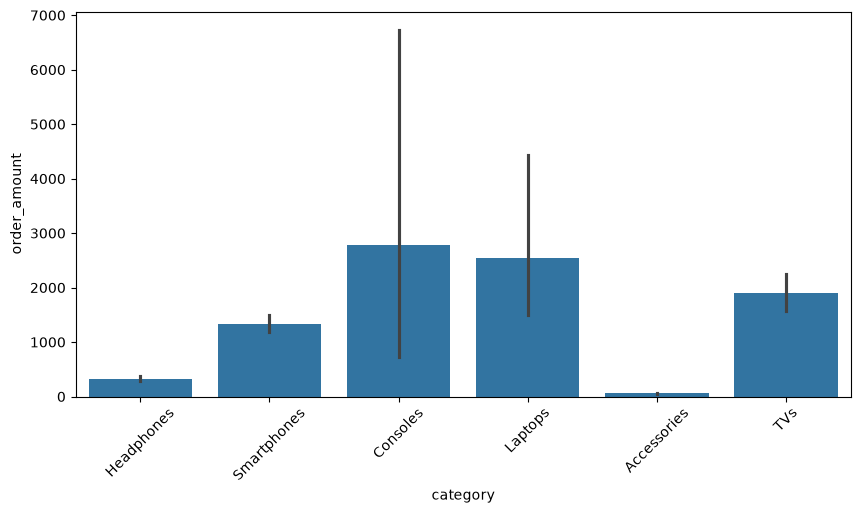

In [36]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='category',
    y='order_amount',
)

plt.xticks(rotation=45)

plt.show()

Наиболее прибыльными направлениями бизнеса являются консоли и лаптопы, немного меньшую выручку приносят телевизоры. 

### 2. Есть ли категории товаров, которые продаются часто, но приносят мало денег?

In [37]:
cstats = df.groupby('category').agg(
    tquantity=('quantity', 'sum'),
    torder_amount=('order_amount', 'sum'),
).reset_index()

cstats 

,category,tquantity,torder_amount
0,Accessories,166,4998.5
1,Consoles,293,136317.5
2,Headphones,145,26383.5
3,Laptops,286,271160.0
4,Smartphones,241,162730.0
5,TVs,107,98645.0


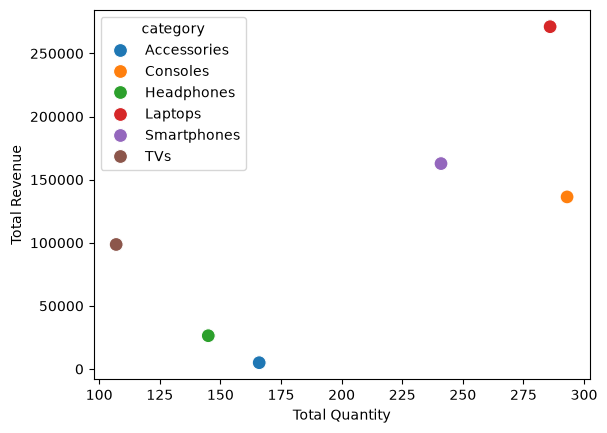

In [38]:
plt.figure()

sns.scatterplot(
    data=cstats,
    x='tquantity',
    y='torder_amount',
    hue='category',
    s=100
)

plt.xlabel('Total Quantity') 
plt.ylabel('Total Revenue')

plt.show()

Категориями товаров, которые продаются часто, но приносят мало денег, являются аксессуары и наушники. 

Для компании может быть выгодно поддерживать такие маленькие категории, так как клиент, при покупке чего-то более дорого, может также решить взять мышку для нового компьютера, контроллер для приставки, или, например, колонку для телевизора. 

### 3. Какие товары являются лидерами продаж?

<Axes: xlabel='product_name'>

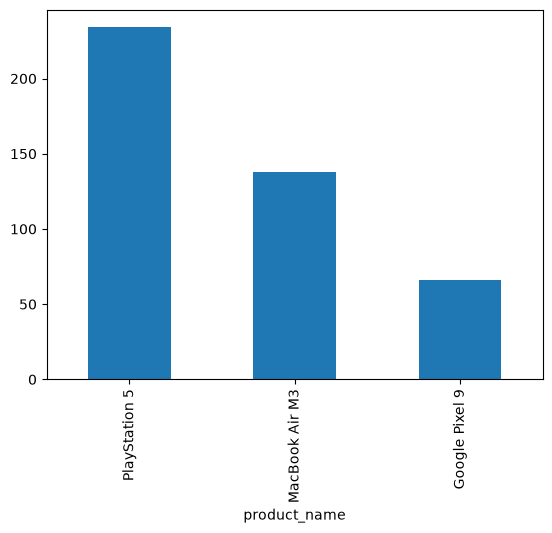

In [39]:
top = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(3)

top.plot(kind='bar')

Наиболее популярными товарами являются: MacBook Air M3, PlaySation 5 и HR Pavilion. 

### 4. Какие товары продаются хуже всего?

<Axes: xlabel='product_name'>

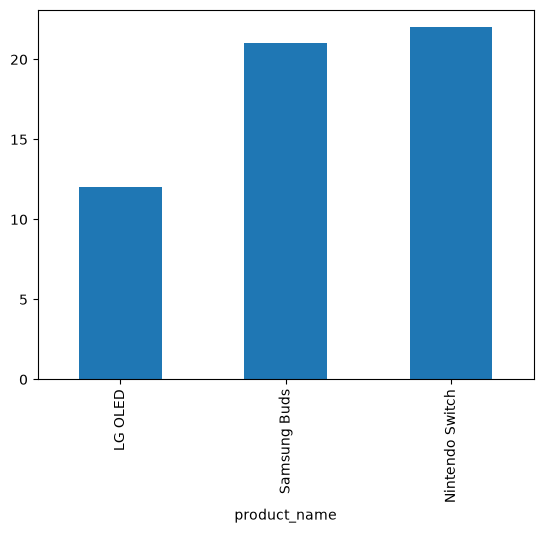

In [40]:
bottom = df.groupby('product_name')['quantity'].sum().sort_values().head(3)
bottom.plot(kind='bar')

Наименее популярными товарами являются: Nintendo Switch, Samsung Buds и LG OLED. 

### 5. В какие месяцы продажи максимальны и минимальны?

<Axes: xlabel='order_date'>

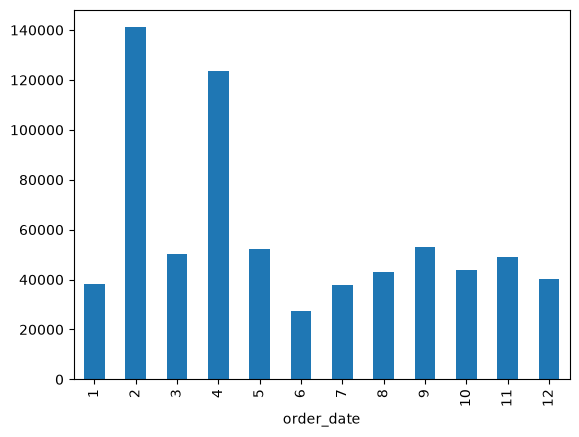

In [41]:
df['order_date'] = pd.to_datetime(df['order_date'])

months = df.groupby(df['order_date'].dt.month)['order_amount'].sum()

months.plot(kind='bar')

Продажи сильно взлетают в феврале, что может быть связано с сезонными праздниками: 14 февраля, 23 февраля, наступающее 8 марта. 

В апреле продажи так же заметно вырастают, оставляя небольшой подъем до мая. Это может быть связано с началом весенних распродаж. 

Продажи заметно опускаются в июне и июле. Это можно объяснить тем, что большое количество людей уезжают в отпуска, готовятся к лету. 

В целом зиму и осень продажи держатся примерно на одном уровне. 

### 6. Есть ли различия в активности покупателей по дням недели?

<Axes: xlabel='order_date'>

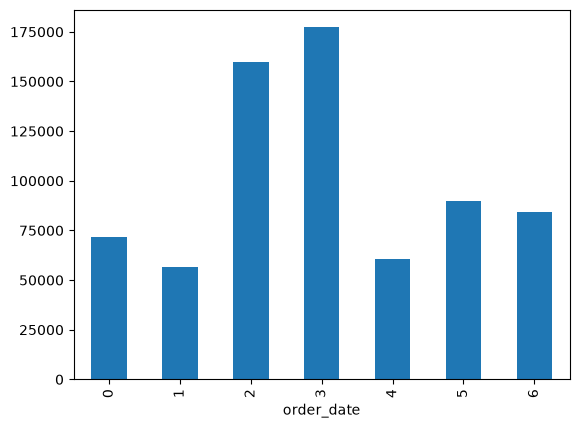

In [42]:
df['order_date'] = pd.to_datetime(df['order_date'])

dayofweek = df.groupby(df['order_date'].dt.dayofweek)['order_amount'].sum()

dayofweek.plot(kind='bar')

Наиболее активными днями являются среда и четверг, а наименее активными - вторник и пятница. 

### 7. Какие регионы являются наиболее прибыльными?

<Axes: xlabel='region'>

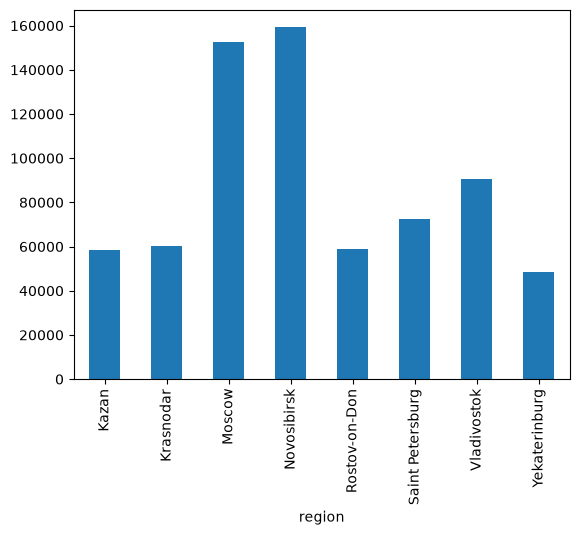

In [43]:
regionstats = df.groupby('region')['order_amount'].sum()

regionstats.plot(kind='bar')

Наиболее прибыльными являются Москва и Новосибирск. 

Остальные регионы сильно им уступают. 

### 8. Есть ли связь между размером скидки и объемом продаж?

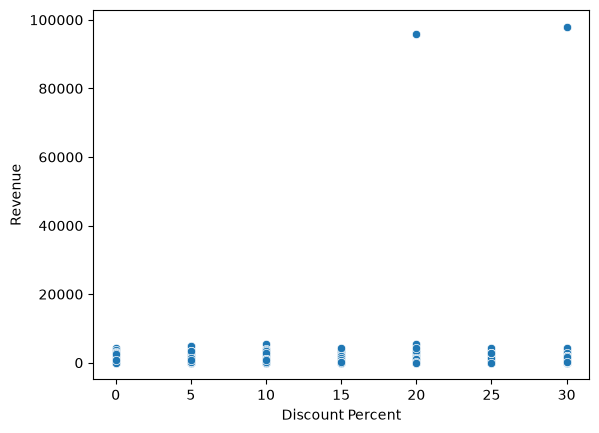

In [44]:
sns.scatterplot(data=df, x='discount_percent', y='order_amount')
plt.xlabel('Discount Percent')
plt.ylabel('Revenue')

plt.show()

Явной зависимости между скидкой и выручкой не наблюдается. Плотность и высота точек практически идентичны на каждом уровне скидок, что показывает, что все товары заказываются примерно в одинаковом объеме вне зависимости от скидок. 

На графике также присутствуют две точки выброса, которые могут отображать единичные оптовые или очень крупные заказы.

### 9. Какие клиенты совершают самые дорогие покупки?

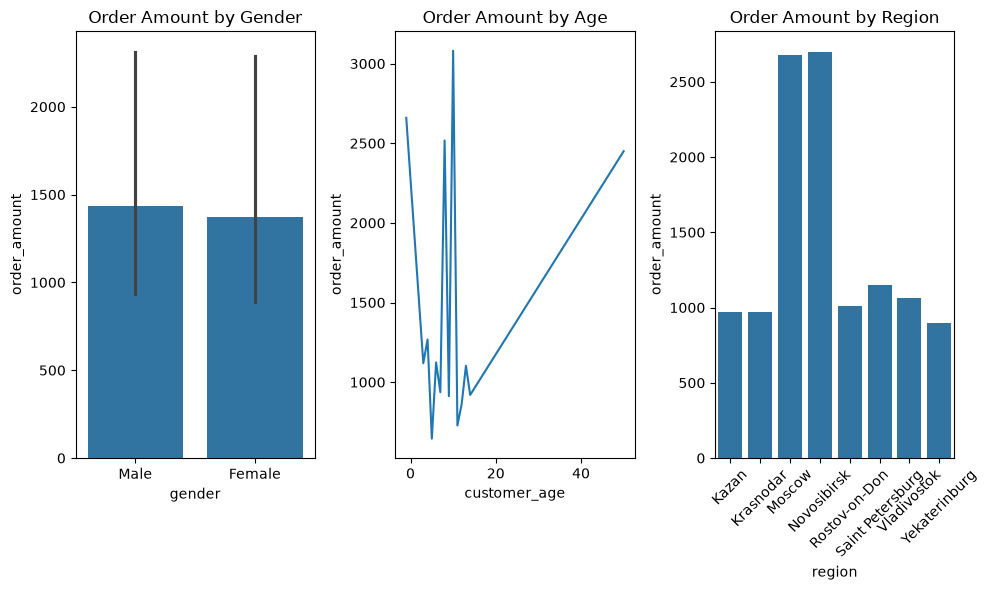

In [51]:
fig, axes = plt.subplots(1, 3,figsize=(10, 6))

sns.barplot(data=df, x='gender', y='order_amount', ax=axes[0])
axes[0].set_title('Order Amount by Gender')

age = df.groupby(df['customer_age']//5)['order_amount'].mean().reset_index()
sns.lineplot(data=age, x='customer_age', y='order_amount', ax=axes[1])
axes[1].set_title('Order Amount by Age')

region = df.groupby('region')['order_amount'].mean().reset_index()
sns.barplot(data=region, x='region', y='order_amount', ax=axes[2])
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_title('Order Amount by Region')

plt.tight_layout()
plt.show()

В количестве покупок с небольшим разрывом выигрывают мужчины. 

Больше всего покупок совершают клиенты в диапазоне от 45 до 55 лет, однако между этими возрастами наблюдается сильная просадка. Меньше всего покупок совершают клиенты в возрастном диапазоне 25-30 лет и 55-65 лет. 

Наибольшее количество заказов приходится на Москву и Новосибирск, как уже выяснилось ранее. 

### 10. Какие товары чаще всего покупаются повторно?

In [50]:
repeated = df[df['is_repeat_customer'] == True]

repprod = repeated.groupby('product_name').size().sort_values(ascending=False).reset_index(name='count')

repprod

,product_name,count
0,Google Pixel 9,18
1,AirPods Pro,17
2,Xiaomi 14,13
3,iPhone 15,12
4,MacBook Air M3,12
5,HP Pavilion,12
6,USB-C Cable,12
7,Xiaomi TV,11
8,ASUS ZenBook,11
9,Lenovo ThinkPad X1,11


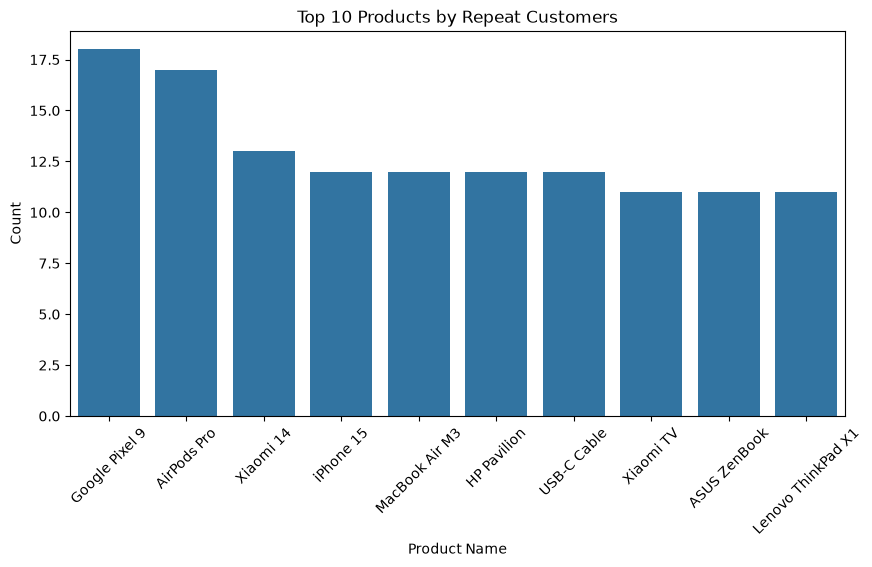

In [47]:
plt.figure(figsize=(10,5))

sns.barplot(data=repprod.head(10), x='product_name', y='count')

plt.xticks(rotation=45)
plt.title('Top 10 Products by Repeat Customers')
plt.xlabel('Product Name')
plt.ylabel('Count')
plt.show()

Чаще всего повторно покупались Google Pixel 9 и AirPods Pro. Чуть реже, но все еще довольно часто, покупались повторно устройства Xiaomi 14. 

### 11. Какие интересные закономерности вы обнаружили самостоятельно?

1. График №5 показывает, что, несмотря на предпраздничный период, в декабре количество заказов по сравнению с другими месяцами не возрастает.

2. В столбце 'Order Amount by Age' графика №9 видно, что после наступления пенсионного возраста(примерно 65 лет) средний размер покупок клиентов заметно возрастает. 

# Этап 3. Бизнес-отчет

## 1. Краткое описание очистки данных

### В ходе подготовки данных были обработаны пропущенные значения:

- customer_age - пропущенные значения были заменены на медианные, чтобы уберечь данные от искажения выявленными выбросами. 

- customer_rating - пропущенные значения были заменены на медианные в целях сохранения представления о действительной оценки магазина. 

- delivery_days - пропущенные значения былт заменены на средние для лучшего понимания логистической ситуации. 

### Обработаны некорректные значения:

- customer_age - возрасты клиентов меньше 18 и больше 90 лет были приведены к медианному значению, чтобы не портить статистику возрастов клиентов.  

- discount_percent - удалены некорректные значения скидок;  

- order_amount, quantity и unit_price - удалены отрицательные значения, так как их появление в датасете было являлось ошибкой и данные оказались некорректны. 

## 2. Основные результаты анализа

- Скидки почти не влияют на количество продаж. 

- Существенной сезонности продаж не было выявлено.

- Некоторые категории и товары значительно отличаются популярностью среди других.

- Отмечена разница в среднем размере покупки в зависимости от возраста и региона клиента. 

## 3. Ответы на вопросы бизнеса

### 1. Товары, приносящие наибольшую выручку:

Наиболее высокую выручку формируют товары категории консолей и ноутбуков. 

### 2. Часто покупаемые товары с наименьшей выручкой:

Категориями товаров, которые продаются часто, но приносят относительно низкую выручку, являются аксессуары и наушники.

Это может указывать на более низкую стоимость товаров или меньшую маржинальность данных категорий.

### 3. Лидеры продаж:

Наиболее популярными товарами являются: MacBook Air M3, PlaySation 5 и HR Pavilion.

### 4. Наименее популярные товары:

Наименее популярными товарами являются: Nintendo Switch, Samsung Buds и LG OLED. 

### 5. Сезонность:

Выраженной сезонности продаж по месяцам не выявлено.

### 6. Активность по дням недели:

Наиболее активными днями являются среда и четверг, а наименее активными - вторник и пятница.

### 7. Регионы:

Наиболее прибыльными регионами являются Москва и Новосибирск.

### 8. Скидки и продажи:

Сильной зависимости между размером скидки и объемом продаж не обнаружено.

### 9. Самые дорогие покупки:

Наибольший средний чек наблюдается у мужчин и клиентов в возрасте 45–55 лет.

### 10. Повторные покупки:

Чаще всего повторно покупались Google Pixel 9 и AirPods Pro.

### 11. Дополнительные закономерности:

- В декабре не наблюдается роста продаж.

- После 65 лет увеличивается средний чек.

# 4. Рекомендации руководству

- Развивать товары с высоким уровнем повторных покупок, так как они формируют лояльность клиентов.

- Усилить маркетинг в регионах с наибольшей выручкой, чтобы максимально увеличить выручку. 

- Провести дополнительный анализ эффективности скидок, так как в нынешней ситуации их влияние на продажи практически отсутствует.  

## 5. Финальный вывод

На основании проведенного анализа текущее состояние бизнеса можно охарактеризовать как стабильное, устойчивое и финансово здоровое.

- Бизнес работает стабильно в течение всего года, без резких сезонных спадов или кризисных месяцев.

- В ассортименте четко выделены товары, которые делают основную кассу и сопутствующие товары, которые покупаются часто и создают постоянный поток заказов.

- У компании есть выраженное наличие покупателей, которые приносят больше всего дохода. 

- Бизнес имеет сильные и прибыльные опорные точки в географии.

У компании нет критических проблем или провалов в продажах, поэтому главная задача сейчас — не исправлять ошибки, а развивать текущий успех.